<a href="https://colab.research.google.com/github/Labannya1038/Machine-Learning/blob/main/Optimization_with_Genetic_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset Download and Inspection**

In [1]:
!wget -O dj38.tsp https://www.math.uwaterloo.ca/tsp/world/dj38.tsp
!head -n 25 dj38.tsp

--2026-02-16 04:41:43--  https://www.math.uwaterloo.ca/tsp/world/dj38.tsp
Resolving www.math.uwaterloo.ca (www.math.uwaterloo.ca)... 129.97.206.21
Connecting to www.math.uwaterloo.ca (www.math.uwaterloo.ca)|129.97.206.21|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1465 (1.4K) [application/dsptype]
Saving to: ‘dj38.tsp’

dj38.tsp            100%[===================>]   1.43K  --.-KB/s    in 0s      

2026-02-16 04:41:44 (18.1 MB/s) - ‘dj38.tsp’ saved [1465/1465]

NAME: dj38
COMMENT : 38 locations in Djibouti
COMMENT : Derived from National Imagery and Mapping Agency data
COMMENT : This file is a corrected version of dj89, where duplications
COMMENT:  have been removed.  Thanks to Jay Muthuswamy and others for
COMMENT:  requesting data sets without duplications.
TYPE: TSP
DIMENSION: 38
EDGE_WEIGHT_TYPE: EUC_2D
NODE_COORD_SECTION
1 11003.611100 42102.500000
2 11108.611100 42373.888900
3 11133.333300 42885.833300
4 11155.833300 42712.500000
5 11183.333300 4293

**Parsing City Coordinates**

In [2]:
import numpy as np

def read_tsplib_coords(path):
    coords = []
    in_section = False
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line == "NODE_COORD_SECTION":
                in_section = True
                continue
            if line == "EOF":
                break
            if in_section and line:
                parts = line.split()
                # format: id x y
                _, x, y = parts[0], float(parts[1]), float(parts[2])
                coords.append((x, y))
    return np.array(coords)

coords = read_tsplib_coords("dj38.tsp")
n = len(coords)
n, coords[:5]


(38,
 array([[11003.6111, 42102.5   ],
        [11108.6111, 42373.8889],
        [11133.3333, 42885.8333],
        [11155.8333, 42712.5   ],
        [11183.3333, 42933.3333]]))

**Distance Matrix Construction**

In [3]:
def dist_matrix(coords):
    n = len(coords)
    D = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(n):
            dx = coords[i,0] - coords[j,0]
            dy = coords[i,1] - coords[j,1]
            D[i,j] = (dx*dx + dy*dy) ** 0.5
    return D

D = dist_matrix(coords)


**GA Components Definition**

In [4]:
import random

def route_length(route, D):
    total = 0.0
    for i in range(len(route)-1):
        total += D[route[i], route[i+1]]
    total += D[route[-1], route[0]]  # return to start
    return total

def fitness(route, D):
    return 1.0 / (1.0 + route_length(route, D))

def init_population(pop_size, n):
    base = list(range(n))
    pop = []
    for _ in range(pop_size):
        r = base[:]
        random.shuffle(r)
        pop.append(r)
    return pop

def tournament_selection(pop, D, k=3):
    candidates = random.sample(pop, k)
    candidates.sort(key=lambda r: fitness(r, D), reverse=True)
    return candidates[0]

# Order Crossover (OX)
def order_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None]*n
    child[a:b+1] = p1[a:b+1]
    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    return child

# Swap mutation
def swap_mutation(route, rate=0.1):
    r = route[:]
    if random.random() < rate:
        i, j = random.sample(range(len(r)), 2)
        r[i], r[j] = r[j], r[i]
    return r

def genetic_algorithm_tsp(D, pop_size=100, generations=300, cx_rate=0.9, mut_rate=0.2):
    n = D.shape[0]
    pop = init_population(pop_size, n)
    best = max(pop, key=lambda r: fitness(r, D))

    for gen in range(generations):
        new_pop = []
        # elitism: keep best
        new_pop.append(best)

        while len(new_pop) < pop_size:
            p1 = tournament_selection(pop, D)
            p2 = tournament_selection(pop, D)

            if random.random() < cx_rate:
                c1 = order_crossover(p1, p2)
                c2 = order_crossover(p2, p1)
            else:
                c1, c2 = p1[:], p2[:]

            c1 = swap_mutation(c1, rate=mut_rate)
            c2 = swap_mutation(c2, rate=mut_rate)

            new_pop.extend([c1, c2])

        pop = new_pop[:pop_size]
        curr_best = max(pop, key=lambda r: fitness(r, D))
        if fitness(curr_best, D) > fitness(best, D):
            best = curr_best

        if (gen+1) % 50 == 0:
            print(f"Gen {gen+1}: best length = {route_length(best, D):.2f}")

    return best

best_route = genetic_algorithm_tsp(D)
print("Best route length:", route_length(best_route, D))


Gen 50: best length = 12127.64
Gen 100: best length = 10615.15
Gen 150: best length = 9953.11
Gen 200: best length = 9734.58
Gen 250: best length = 8813.31
Gen 300: best length = 8704.14
Best route length: 8704.144600282121


**GA Execution and Convergence Analysis**

Best route length: 7343.598111342497


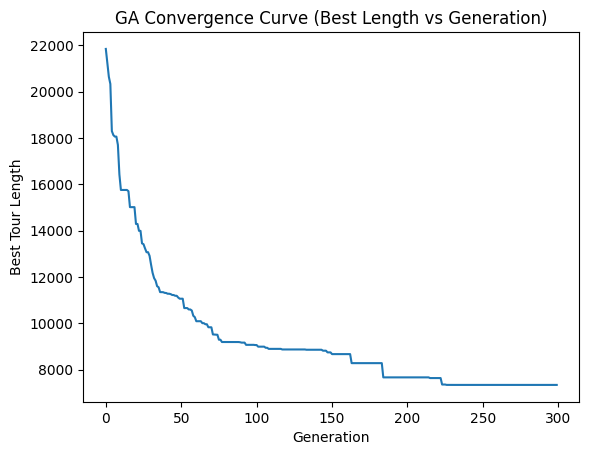

In [5]:
import random
import matplotlib.pyplot as plt

def genetic_algorithm_tsp_with_curve(D, pop_size=100, generations=300, cx_rate=0.9, mut_rate=0.2):
    n = D.shape[0]
    pop = init_population(pop_size, n)
    best = max(pop, key=lambda r: fitness(r, D))

    best_lengths = []  # <-- curve data

    for gen in range(generations):
        new_pop = []
        new_pop.append(best)  # elitism

        while len(new_pop) < pop_size:
            p1 = tournament_selection(pop, D)
            p2 = tournament_selection(pop, D)

            if random.random() < cx_rate:
                c1 = order_crossover(p1, p2)
                c2 = order_crossover(p2, p1)
            else:
                c1, c2 = p1[:], p2[:]

            c1 = swap_mutation(c1, rate=mut_rate)
            c2 = swap_mutation(c2, rate=mut_rate)

            new_pop.extend([c1, c2])

        pop = new_pop[:pop_size]
        curr_best = max(pop, key=lambda r: fitness(r, D))
        if fitness(curr_best, D) > fitness(best, D):
            best = curr_best

        best_lengths.append(route_length(best, D))  # <-- save best length each generation

    return best, best_lengths

best_route, curve = genetic_algorithm_tsp_with_curve(D)

print("Best route length:", route_length(best_route, D))

# Plot the curve
plt.figure()
plt.plot(curve)
plt.xlabel("Generation")
plt.ylabel("Best Tour Length")
plt.title("GA Convergence Curve (Best Length vs Generation)")
plt.show()
